# Graphics

In [18]:
import sys
from pathlib import Path

# Jupyter has no __file__ to anchor a relative import on, and the notebook's
# kernel env may not have the package installed -> add the repo root by hand.
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import nd_phase_unwrap.io as io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn # For visualization of pandas df
import dabest

## 4D Phantom

### Heatmap

In [19]:
data_path = REPO_ROOT / 'test_data'
in_path = data_path / '3+1D_phantom'
out_paths = {
    'IGC': data_path / 'IGC_unwrapped',
    'Laplace': data_path / 'Laplace_unwrapped',
    'ROMEO': data_path / 'ROMEO_unwrapped',
}
# 0 wraps == ground truth (div_factor = 1 + 2*0 leaves the phase untouched)
truth_path = in_path / "0wraps.npy"

truth_array = np.angle(io.load_numpy_data(truth_path))
mask = (np.abs(truth_array) != 0).astype(bool)

# save results in dataframe
row_indices = list(range(6))
col_indices = list(np.arange(1.0, 3.5, 0.5)) + ["no noise"]

heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=row_indices, columns=col_indices)
    heatmap_df.columns.name = "VNR"
    heatmap_df.index.name = "wraps"

    for file in os.listdir(in_path):
        file = Path(file)
        if not file.name.endswith(".npy"):
            continue
        if "VNR" in file.stem:
            vnr = float(file.stem[-3:].replace("_", "."))
        else:
            vnr = "no noise"
        wrapcount = int(file.stem[0])
        div_factor = 1 + 2*wrapcount

        unwrapped_path = out_path / f'{file.stem}_unwrapped.npy'
        if not unwrapped_path.is_file():
            continue
        out_array = io.load_numpy_data(unwrapped_path) / div_factor

        diff = np.abs(truth_array - out_array) < 1.5*np.pi / div_factor
        heatmap_df.at[wrapcount, vnr] = diff[mask].mean()

    heatmaps[algorithm] = heatmap_df


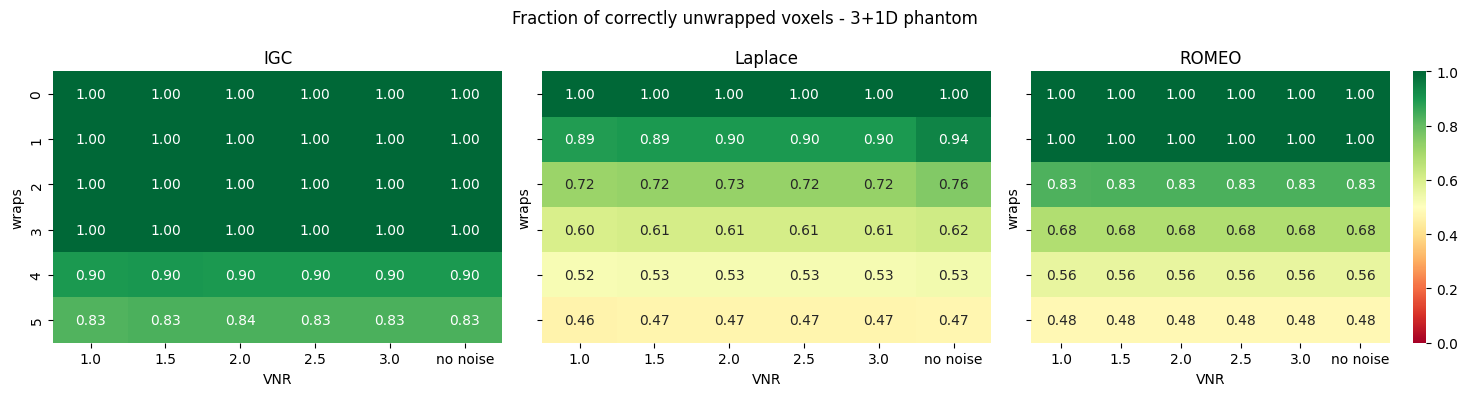

In [20]:
fig, axes = plt.subplots(1, len(heatmaps), figsize=(5 * len(heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt='.2f', vmin=0.0,
               cmap='RdYlGn', cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle('Fraction of correctly unwrapped voxels - 3+1D phantom')
fig.tight_layout()
# Save fig
# fig.savefig(data_path / '3+1D_phantom_heatmap.png', dpi=150)

## RACLETTE data

### Heatmap

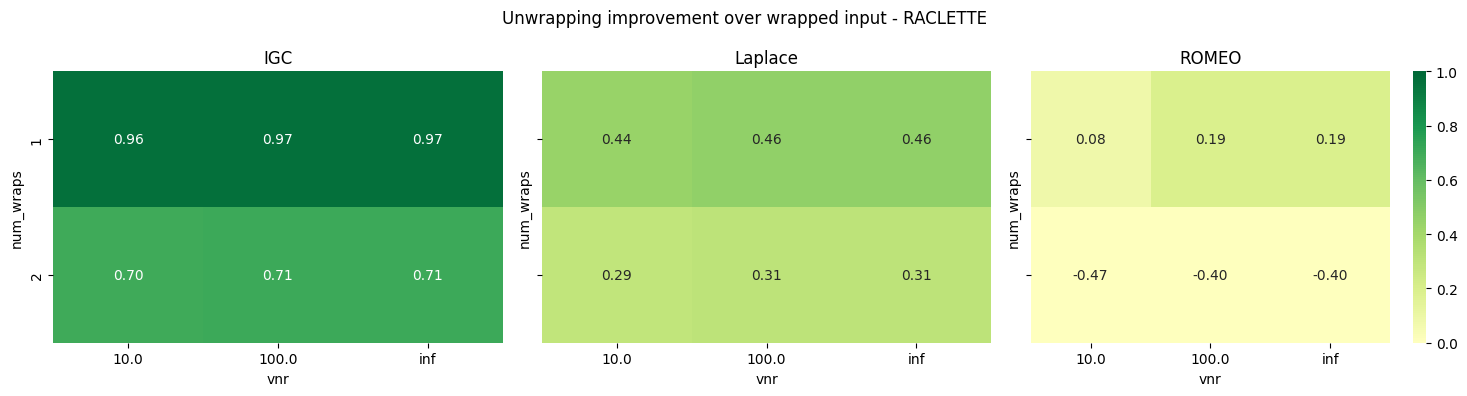

In [21]:
raclette_dir = data_path / 'raclette_eval'
BASELINE = 'wrapped (no unwrapping)'

summary = pd.read_csv(raclette_dir / 'raclette_eval_summary.csv')
pre = summary[summary.algorithm == BASELINE].set_index(['num_wraps', 'vnr'])['correct_fraction_mean']
summary['improvement'] = summary.apply(
    lambda r: (r.correct_fraction_mean - pre[r.num_wraps, r.vnr]) / (1 - pre[r.num_wraps, r.vnr]), axis=1)

algorithms = [a for a in summary.algorithm.unique() if a != BASELINE]
fig, axes = plt.subplots(1, len(algorithms), figsize=(5 * len(algorithms), 4), sharey=True)
for axis, algo in zip(axes, algorithms):
    pivot = summary[summary.algorithm == algo].pivot(index='num_wraps', columns='vnr', values='improvement')
    sn.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, cbar=axis is axes[-1], ax=axis, vmin=0, vmax=1)
    axis.set_title(algo)
fig.suptitle('Unwrapping improvement over wrapped input - RACLETTE')
fig.tight_layout()


### Cummings plot (DABEST)

c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 1.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


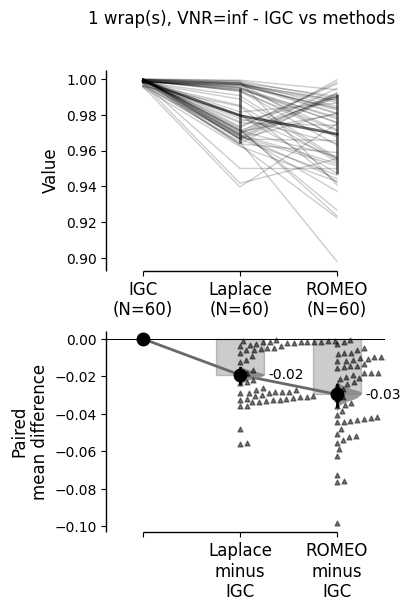

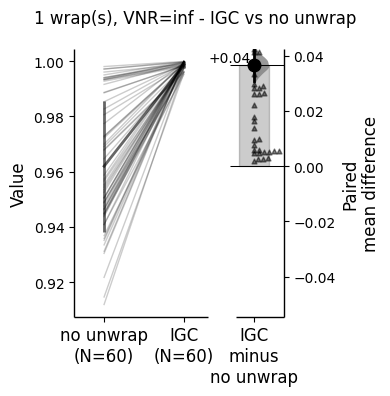

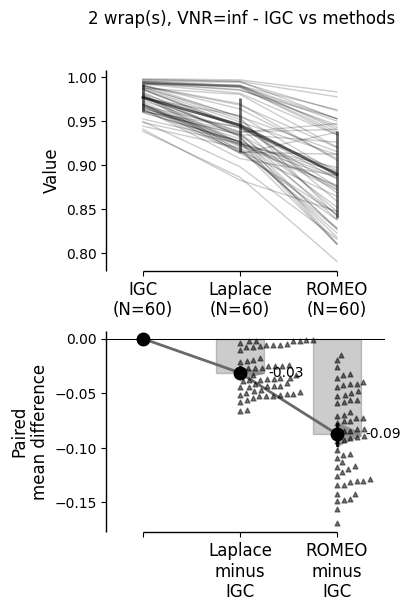

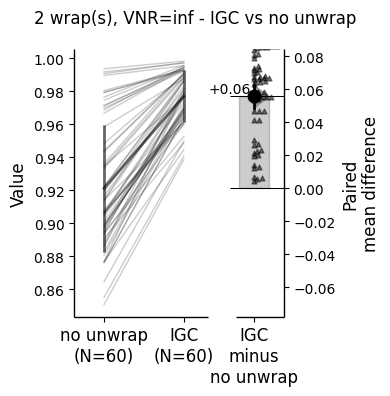

In [22]:
cases = pd.read_csv(raclette_dir / "raclette_eval_cases.csv")

for wraps in (1, 2):
    wide = (cases[(cases.vnr == np.inf) & (cases.num_wraps == wraps)]
            .pivot(index="subject", columns="algorithm", values="correct_fraction")
            .reset_index()
            .rename(columns={BASELINE: "no unwrap"}))  # dabest reads labels as regex; parens break it

    fig = dabest.load(wide, idx=("IGC", "Laplace", "ROMEO"), paired="baseline", id_col="subject").mean_diff.plot()
    fig.suptitle(f"{wraps} wrap(s), VNR=inf - IGC vs methods")

    fig = dabest.load(wide, idx=("no unwrap", "IGC"), paired="baseline", id_col="subject").mean_diff.plot()
    fig.suptitle(f"{wraps} wrap(s), VNR=inf - IGC vs no unwrap")


Do the same for RACLETTE

# Clin dataset
Segment??
Show slice with max wrap and print a before and after image

### Heatmap

In [23]:
clin_path = data_path / "clin_4d_data"
gt_path = clin_path / "clin_4d_data_gt"

subjects = sorted({f.split("_a350")[0] for f in os.listdir(clin_path) if f.endswith(".npy")})
wraps = [1, 2]

clin_heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=wraps, columns=subjects)
    heatmap_df.index.name = "wraps"
    heatmap_df.columns.name = "subject"

    for subject in subjects:
        truth_array = np.angle(io.load_numpy_data(gt_path / f"{subject}_a350.npy"))
        mask = np.abs(truth_array) != 0
        for wrapcount in wraps:
            div_factor = 1 + 2 * wrapcount
            unwrapped_path = out_path / f"{subject}_a350_{wrapcount}wraps_unwrapped.npy"
            if not unwrapped_path.is_file():
                continue
            out_array = io.load_numpy_data(unwrapped_path) / div_factor
            diff = np.abs(truth_array - out_array) < 1.5 * np.pi / div_factor
            heatmap_df.at[wrapcount, subject] = diff[mask].mean()
    heatmap_df["mean"] = heatmap_df[subjects].mean(axis=1)
    clin_heatmaps[algorithm] = heatmap_df


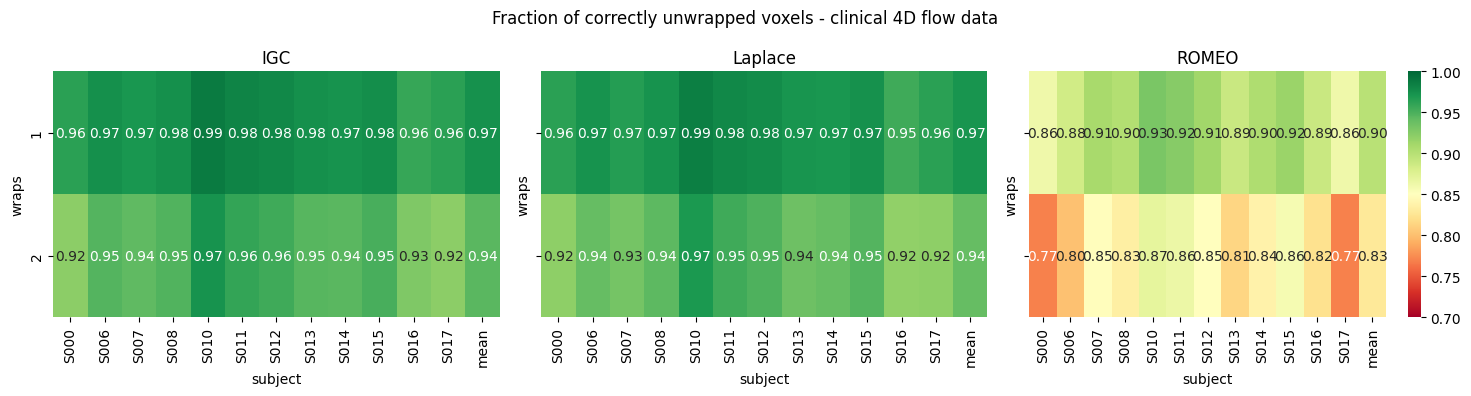

In [24]:
fig, axes = plt.subplots(1, len(clin_heatmaps), figsize=(5 * len(clin_heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, clin_heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt=".2f", vmin=0.7, vmax=1.0,
               cmap="RdYlGn", cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle("Fraction of correctly unwrapped voxels - clinical 4D flow data")
fig.tight_layout()
